In [11]:
import pandas as pd

df = pd.read_excel('C:/Users/TANUSHREE/Desktop/Data Analyst project/customer_shopping_behavior.xlsx')


In [12]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [15]:
df.describe(include='all')


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
count,5050.000000,5050.000000,5050,5050,5050,4494.000000,5050,4680,5050,5050,4449.000000,5050,5050,5050,4502.000000,5050,5050
unique,NaN,NaN,3,30,5,NaN,54,4,25,5,NaN,2,6,2,NaN,6,7
top,NaN,NaN,Male,Shirt,Clothing,NaN,New York,M,Black,Spring,NaN,No,Standard,No,NaN,Credit Card,Monthly
freq,NaN,NaN,3018,320,2130,NaN,337,1981,404,1280,NaN,3462,1213,2789,NaN,954,946
mean,2519.570891,44.150495,NaN,NaN,NaN,144.765236,NaN,NaN,NaN,NaN,3.668195,NaN,NaN,NaN,25.221901,NaN,NaN
std,1470.402964,15.282328,NaN,NaN,NaN,275.590101,NaN,NaN,NaN,NaN,0.865357,NaN,NaN,NaN,14.521635,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,10.120000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN
25%,1252.250000,31.000000,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,13.000000,NaN,NaN
50%,2499.500000,44.000000,NaN,NaN,NaN,65.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,25.000000,NaN,NaN
75%,3740.750000,57.000000,NaN,NaN,NaN,89.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,38.000000,NaN,NaN


In [16]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [25]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)

In [26]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [27]:
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(
    df['Purchase Amount (USD)'].median()
)

In [29]:
df['Size'] = df['Size'].fillna(df['Size'].mode()[0])

In [30]:
df['Previous Purchases'] = df['Previous Purchases'].fillna(
    df['Previous Purchases'].median()
)

In [31]:
print(df.isnull().sum())

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [40]:
df.columns = df.columns.str.replace('_', '')
print(df.columns)

Index(['customer id', 'age', 'gender', 'item purchased', 'category',
       'purchase amount (usd)', 'location', 'size', 'color', 'season',
       'review rating', 'subscription status', 'shipping type',
       'discount applied', 'previous purchases', 'payment method',
       'frequency of purchases'],
      dtype='object')


In [41]:
df['purchase frequency days'] = df['frequency of purchases'].map({
    'Weekly': 7,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Annually': 365
})

In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer id              5050 non-null   int64  
 1   age                      5050 non-null   int64  
 2   gender                   5050 non-null   object 
 3   item purchased           5050 non-null   object 
 4   category                 5050 non-null   object 
 5   purchase amount (usd)    5050 non-null   float64
 6   location                 5050 non-null   object 
 7   size                     5050 non-null   object 
 8   color                    5050 non-null   object 
 9   season                   5050 non-null   object 
 10  review rating            5050 non-null   float64
 11  subscription status      5050 non-null   object 
 12  shipping type            5050 non-null   object 
 13  discount applied         5050 non-null   object 
 14  previous purchases      

In [43]:
print(df['frequency of purchases'].unique())

['Weekly' 'Quarterly' 'Monthly' 'Annually' 'Every 3 Months' 'Bi-Weekly'
 'Fortnightly']


In [44]:
df['frequency of purchases'] = df['frequency of purchases'].str.strip().str.lower()

In [45]:
df['purchase frequency days'] = df['frequency of purchases'].map({
    'weekly': 7,
    'bi-weekly': 14,
    'monthly': 30,
    'quarterly': 90,
    'annually': 365
})

In [46]:
print(df['purchase frequency days'].isnull().sum())

1140


In [47]:
df['frequency of purchases'] = df['frequency of purchases'].str.strip().str.lower()

df['purchase frequency days'] = df['frequency of purchases'].replace({
    'weekly': 7,
    'bi-weekly': 14,
    'fortnightly': 14,
    'monthly': 30,
    'quarterly': 90,
    'every 3 months': 90,
    'annually': 365
})

C:\Users\TANUSHREE\AppData\Local\Temp\ipykernel_15748\2651261469.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['purchase frequency days'] = df['frequency of purchases'].replace({


In [48]:
print(df['purchase frequency days'].isnull().sum())

0


In [54]:
df.head()

,customer id,age,gender,item purchased,category,purchase amount (usd),location,size,color,season,review rating,subscription status,shipping type,discount applied,previous purchases,payment method,frequency of purchases,purchase frequency days
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,weekly,7
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,quarterly,90
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,monthly,30
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,annually,365
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,weekly,7


In [57]:
df[['purchase frequency days','frequency of purchases']].head(10)

,purchase frequency days,frequency of purchases
0,7,weekly
1,90,quarterly
2,30,monthly
3,365,annually
4,7,weekly
5,365,annually
6,90,every 3 months
7,365,annually
8,14,bi-weekly
9,30,monthly


In [59]:
df['promocode used'] = df['discount applied'].map({
    'Yes': 'Yes',
    'No': 'No'
})

In [60]:
df[['discount applied','promocode used']].head()

,discount applied,promocode used
0,No,No
1,Yes,Yes
2,No,No
3,No,No
4,No,No


In [61]:
df[['discount applied','promocode used']]

,discount applied,promocode used
0,No,No
1,Yes,Yes
2,No,No
3,No,No
4,No,No
...,...,...
5045,Yes,Yes
5046,No,No
5047,No,No
5048,No,No


In [62]:
df['promocode used'] = df['discount applied']

In [67]:
df[['discount applied','promocode used']].head(7)

,discount applied,promocode used
0,No,No
1,Yes,Yes
2,No,No
3,No,No
4,No,No
5,No,No
6,Yes,Yes


In [64]:
df.groupby('promocode used')['purchase amount (usd)'].mean()

promocode used
No     124.164529
Yes    150.561743
Name: purchase amount (usd), dtype: float64

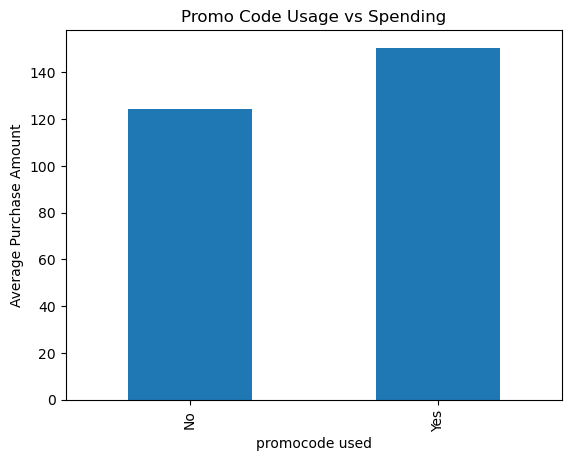

In [65]:
import matplotlib.pyplot as plt

df.groupby('promocode used')['purchase amount (usd)'].mean().plot(kind='bar')
plt.title('Promo Code Usage vs Spending')
plt.ylabel('Average Purchase Amount')
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [11]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64